In [38]:
#IMPORT MODULES AND LIBRARIES
#::::::::::::::::
#1 READ DATA
import pandas as pd

#2 DATA PROCESSING
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report,confusion_matrix

#3 HANDLING IMBALANCE DATA
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as Imbpipeline

#4 VISUALIZATION
import seaborn as sns
import matplotlib.pyplot as plt

#MODEL
import sklearn
from sklearn.ensemble import RandomForestClassifier

#SAVING
import joblib


In [39]:
df=pd.read_csv("datasets/healthcare_disease_prediction_dataset.csv")

In [40]:
#Print the first 5 and last 5 columns to see the nature of the data
print("FIRST FIVE COLUMNS")
print(df.head())

FIRST FIVE COLUMNS
   Age  Gender Blood Pressure Cholesterol Glucose Smoking Alcohol Consumption  \
0   69    Male           High        High    High     Yes                  No   
1   32    Male            Low        High  Normal     Yes                  No   
2   89  Female         Normal        High  Normal      No                  No   
3   78    Male           High        High    High      No                  No   
4   38    Male            Low      Normal  Normal     Yes                 Yes   

  Exercise        BMI Family History  Heart Disease  Diabetes  Stroke  \
0       No  35.671099             No              1         0       0   
1      Yes  38.554188            Yes              0         1       0   
2      Yes  18.932964            Yes              1         0       0   
3      Yes  21.806350            Yes              0         1       1   
4      Yes  37.552683             No              0         0       0   

   Kidney Disease  Cancer  Alzheimer's Disease  COPD  L

In [41]:
#The last five columns
print("LAST FIVE COLUMNS")
print(df.tail())

LAST FIVE COLUMNS
     Age  Gender Blood Pressure Cholesterol Glucose Smoking  \
995   27  Female            Low        High  Normal      No   
996   51  Female           High        High  Normal      No   
997   72  Female         Normal        High  Normal     Yes   
998   49    Male         Normal        High    High     Yes   
999   67    Male           High      Normal  Normal     Yes   

    Alcohol Consumption Exercise        BMI Family History  Heart Disease  \
995                  No       No  31.960176            Yes              1   
996                 Yes      Yes  20.118492            Yes              0   
997                  No       No  20.916536            Yes              0   
998                  No      Yes  19.560143            Yes              0   
999                  No      Yes  24.035803            Yes              0   

     Diabetes  Stroke  Kidney Disease  Cancer  Alzheimer's Disease  COPD  \
995         0       0               0       0                   

In [42]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   Gender               1000 non-null   object 
 2   Blood Pressure       1000 non-null   object 
 3   Cholesterol          1000 non-null   object 
 4   Glucose              1000 non-null   object 
 5   Smoking              1000 non-null   object 
 6   Alcohol Consumption  1000 non-null   object 
 7   Exercise             1000 non-null   object 
 8   BMI                  1000 non-null   float64
 9   Family History       1000 non-null   object 
 10  Heart Disease        1000 non-null   int64  
 11  Diabetes             1000 non-null   int64  
 12  Stroke               1000 non-null   int64  
 13  Kidney Disease       1000 non-null   int64  
 14  Cancer               1000 non-null   int64  
 15  Alzheimer's Disease  1000 non-null   in

In [43]:
print(df.describe())

               Age          BMI  Heart Disease     Diabetes       Stroke  \
count  1000.000000  1000.000000    1000.000000  1000.000000  1000.000000   
mean     52.881000    29.213037       0.253000     0.186000     0.134000   
std      20.958915     6.196368       0.434948     0.389301     0.340823   
min      18.000000    18.504881       0.000000     0.000000     0.000000   
25%      34.750000    23.924004       0.000000     0.000000     0.000000   
50%      52.500000    28.892349       0.000000     0.000000     0.000000   
75%      71.000000    34.663806       1.000000     0.000000     0.000000   
max      89.000000    39.974048       1.000000     1.000000     1.000000   

       Kidney Disease      Cancer  Alzheimer's Disease        COPD  \
count     1000.000000  1000.00000          1000.000000  1000.00000   
mean         0.142000     0.10000             0.130000     0.10100   
std          0.349225     0.30015             0.336472     0.30148   
min          0.000000     0.00000  

In [44]:
#Drop Unneeded Column(Family History)
df.drop("Family History", axis=1, inplace=True)

In [45]:
#CLEAN FEATURE COLUMNS BY ENCODING BECAUSE COMPUTERS DOES NOT UNDERSTAND TEXT
ln=LabelEncoder()
features=[
    "Age","Gender","Blood Pressure","Cholesterol","Glucose","Smoking","Alcohol Consumption","Exercise"
]
for col in features:
    df[col]=ln.fit_transform(df[col])


y=ln.fit_transform(df["Diabetes"])




In [66]:
print(df.head())

   Age  Gender  Blood Pressure  Cholesterol  Glucose  Smoking  \
0   51       1               0            0        0        1   
1   14       1               1            0        1        1   
2   71       0               2            0        1        0   
3   60       1               0            0        0        0   
4   20       1               1            1        1        1   

   Alcohol Consumption  Exercise        BMI  Heart Disease  Diabetes  Stroke  \
0                    0         0  35.671099              1         0       0   
1                    0         1  38.554188              0         1       0   
2                    0         1  18.932964              1         0       0   
3                    0         1  21.806350              0         1       1   
4                    1         1  37.552683              0         0       0   

   Kidney Disease  Cancer  Alzheimer's Disease  COPD  Liver Disease  \
0               0       1                    0     0     

In [46]:
feature_col=[
    "Age","Gender","Blood Pressure","Cholesterol","Glucose","Smoking","Alcohol Consumption","Exercise","BMI"
]

In [47]:
#SPLIT DATA INTO X AND Y WHERE X IS FEATURES AND Y LABEL OR TARGET COLUMN
X=df[feature_col]
y=df["Diabetes"]

In [48]:
#TRAIN AMD TEST SPLIT (80/20)
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [49]:
#BALANCING USING SMOTE
smote=SMOTE(random_state=42)


In [50]:
#SCALING
scaler = StandardScaler()

In [51]:
#MODEL
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

In [52]:
#PIPELINING
pipeline=Imbpipeline(steps=[
     ("scaler", scaler),
    ("smote", smote),
    ("model", model)
 ]
)

In [53]:
#CROSS VALIDATION
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

print("\nCV Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())


CV Scores: [0.70140931 0.73651515 0.70048126 0.72426471 0.7009592 ]
Mean CV F1: 0.7127259249671775


In [54]:
#TRAIN MODEL
pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,n_estimators,300


In [55]:
#PREDICTION
y_pred = pipeline.predict(X_test)

In [63]:
#MODEL EVALUATION
print("EVALUATION RESULTS")
print(classification_report(y_test,y_pred))
print(classification_report(
    y_test,
    y_pred,

))

EVALUATION RESULTS
              precision    recall  f1-score   support

           0       0.81      0.93      0.87       163
           1       0.14      0.05      0.08        37

    accuracy                           0.77       200
   macro avg       0.48      0.49      0.47       200
weighted avg       0.69      0.77      0.72       200

              precision    recall  f1-score   support

           0       0.81      0.93      0.87       163
           1       0.14      0.05      0.08        37

    accuracy                           0.77       200
   macro avg       0.48      0.49      0.47       200
weighted avg       0.69      0.77      0.72       200



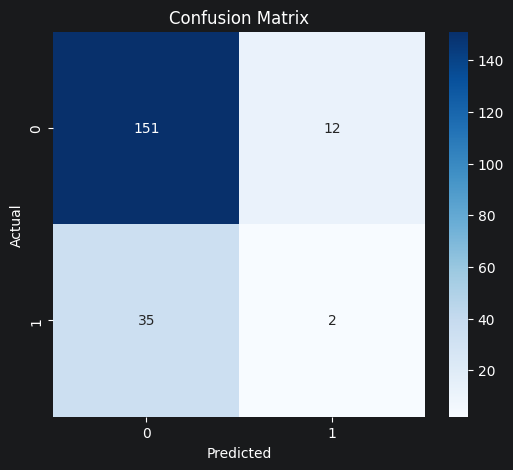

In [57]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=ln.classes_,
            yticklabels=ln.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

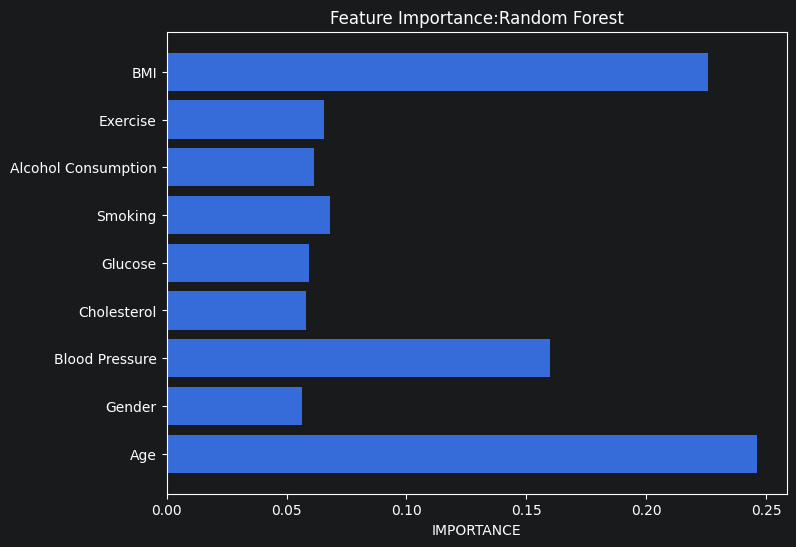

In [58]:
importances = pipeline.named_steps["model"].feature_importances_

plt.figure(figsize=(8, 6))
plt.barh(feature_col, importances)
plt.title("Feature Importance:Random Forest")
plt.xlabel("IMPORTANCE")
plt.show()

In [65]:
model_info = {
    "model": model,
    "sklearn_version": sklearn.__version__
}

joblib.dump(model_info, "model.pkl")
joblib.dump(pipeline, "disease_model.pkl")
joblib.dump(ln, "label__encoder.pkl")

print("\nModel saved successfully!")


Model saved successfully!
